<a href="https://colab.research.google.com/github/andrearuvalcaba6445-netizen/Tareas/blob/main/Unidad_1/Miniproyecto/Vidaurri_y_Natalia_Mini_proy_U1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [ ]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.4 MB/s eta 0:00:00


In [ ]:
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

torch.manual_seed(42)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [ ]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])
# COMPLETAR CARGAR IMAGENES DE ENTRENAMIENTO Y PRUEBA Y GENERAR UN SUBCONJUNTO
trainset_completo = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

tamano_train = 10000
tamano_val = 2000
tamano_resto = len(trainset_completo) - tamano_train - tamano_val

train_subset, val_subset, _ = torch.utils.data.random_split(
    trainset_completo,
    [tamano_train, tamano_val, tamano_resto],
    generator=torch.Generator().manual_seed(42)
)

nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamano del set de entrenamiento completo:", len(trainset_completo))
print("Tamano del set de prueba:", len(testset))

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamano del set de entrenamiento completo: 50000
Tamano del set de prueba: 10000


### 1.1 Subconjuntos de trabajo



Entrenamiento: 10000 imagenes  |  Validacion: 2000  |  Prueba: 10000


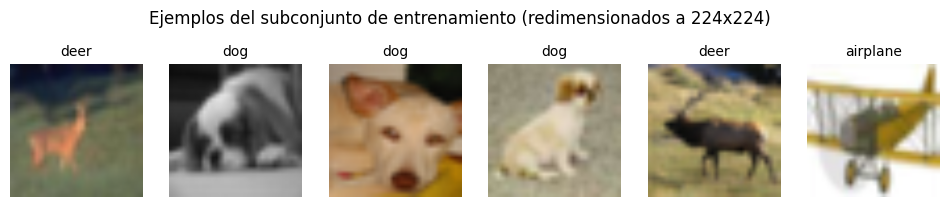

In [ ]:
BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset)} imagenes  |  Validacion: {len(val_subset)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


In [ ]:
# COMPLETAR construir_resnet18(n_clases=10)
#COMPLETAR  construir_efficientnet_b0(n_clases=10)

def construir_resnet18(n_clases=10):
    modelo = models.resnet18(weights="DEFAULT")
    modelo.fc = nn.Linear(modelo.fc.in_features, n_clases)
    return modelo
def construir_efficientnet_b0(n_clases=10):
    modelo = models.efficientnet_b0(weights="DEFAULT")
    modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, n_clases)
    return modelo

modelo_resnet = construir_resnet18(n_clases=10)
modelo_efficientnet = construir_efficientnet_b0(n_clases=10)

print(modelo_resnet)
print(modelo_efficientnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 82.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [ ]:
def crear_metricas(n_clases=10):
    return {
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            salida = modelo(imagenes)
            perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                perdida.backward()
                optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los van a necesitar tal cual para el reporte de diseno (Parte 7).


In [ ]:
N_EPOCAS = 5
LEARNING_RATE = 0.0001
perdida_fn = nn.CrossEntropyLoss()

def entrenar_modelo(modelo, nombre_modelo):

    modelo = modelo.to(DISPOSITIVO)
    optimizador = optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

    metricas_train = crear_metricas(n_clases=10)
    metricas_val = crear_metricas(n_clases=10)

    historial = []

    print(f"\n Entrenando {nombre_modelo}")
    for epoca in range(1, N_EPOCAS + 1):
        inicio = time.time()

        res_train = correr_epoca(modelo, train_loader, perdida_fn, metricas_train, optimizador)
        res_val = correr_epoca(modelo, val_loader, perdida_fn, metricas_val, optimizador=None)

        duracion = time.time() - inicio

        print(f"Epoca [{epoca}/{N_EPOCAS}] ({duracion:.1f}s) | "
              f"Train Loss: {res_train['loss']:.4f} Acc: {res_train['accuracy']:.4f} | "
              f"Val Loss: {res_val['loss']:.4f} Acc: {res_val['accuracy']:.4f}")

        historial.append({
            "epoca": epoca,
            "train_loss": res_train["loss"],
            "train_acc": res_train["accuracy"],
            "val_loss": res_val["loss"],
            "val_acc": res_val["accuracy"],
            "tiempo_seg": duracion,
        })

    return pd.DataFrame(historial)

df_historial_resnet = entrenar_modelo(modelo_resnet, "ResNet-18")
df_historial_efficientnet = entrenar_modelo(modelo_efficientnet, "EfficientNet-B0")


 Entrenando ResNet-18
Epoca [1/5] (39.8s) | Train Loss: 0.5671 Acc: 0.8164 | Val Loss: 0.2760 Acc: 0.9056
Epoca [2/5] (40.2s) | Train Loss: 0.1561 Acc: 0.9553 | Val Loss: 0.2781 Acc: 0.9045
Epoca [3/5] (41.5s) | Train Loss: 0.0597 Acc: 0.9856 | Val Loss: 0.2713 Acc: 0.9159
Epoca [4/5] (41.5s) | Train Loss: 0.0259 Acc: 0.9956 | Val Loss: 0.2415 Acc: 0.9208
Epoca [5/5] (41.2s) | Train Loss: 0.0217 Acc: 0.9956 | Val Loss: 0.2572 Acc: 0.9153

 Entrenando EfficientNet-B0
Epoca [1/5] (59.1s) | Train Loss: 0.9156 Acc: 0.7300 | Val Loss: 0.2840 Acc: 0.9124
Epoca [2/5] (59.9s) | Train Loss: 0.2831 Acc: 0.9100 | Val Loss: 0.1899 Acc: 0.9354
Epoca [3/5] (58.9s) | Train Loss: 0.1602 Acc: 0.9512 | Val Loss: 0.1688 Acc: 0.9442
Epoca [4/5] (59.9s) | Train Loss: 0.1089 Acc: 0.9667 | Val Loss: 0.1609 Acc: 0.9438
Epoca [5/5] (59.2s) | Train Loss: 0.0750 Acc: 0.9778 | Val Loss: 0.1922 Acc: 0.9332


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


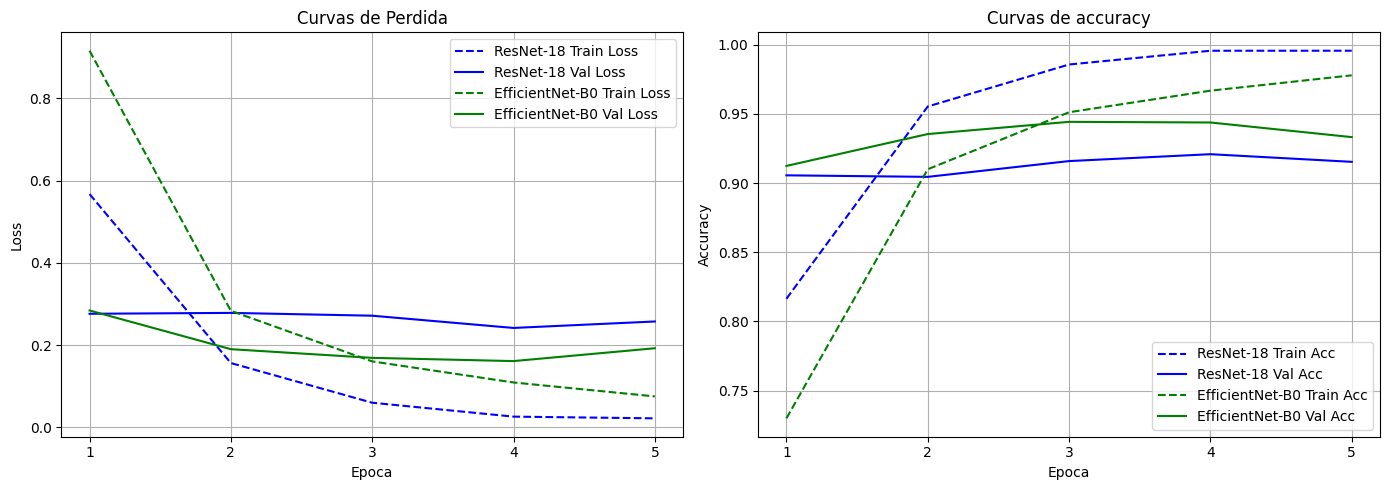

Gap train/val final (accuracy) - ResNet-18:      0.0803
Gap train/val final (accuracy) - EfficientNet-B0: 0.0446


In [ ]:
plt.figure(figsize=(14, 5))

#Grafica de perdida
plt.subplot(1, 2, 1)
plt.plot(df_historial_resnet['epoca'], df_historial_resnet['train_loss'], 'b--', label='ResNet-18 Train Loss')
plt.plot(df_historial_resnet['epoca'], df_historial_resnet['val_loss'], 'b-', label='ResNet-18 Val Loss')
plt.plot(df_historial_efficientnet['epoca'], df_historial_efficientnet['train_loss'], 'g--', label='EfficientNet-B0 Train Loss')
plt.plot(df_historial_efficientnet['epoca'], df_historial_efficientnet['val_loss'], 'g-', label='EfficientNet-B0 Val Loss')
plt.title("Curvas de Perdida")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

#Grafica de accuracy
plt.subplot(1, 2, 2)
plt.plot(df_historial_resnet['epoca'], df_historial_resnet['train_acc'], 'b--', label='ResNet-18 Train Acc')
plt.plot(df_historial_resnet['epoca'], df_historial_resnet['val_acc'], 'b-', label='ResNet-18 Val Acc')
plt.plot(df_historial_efficientnet['epoca'], df_historial_efficientnet['train_acc'], 'g--', label='EfficientNet-B0 Train Acc')
plt.plot(df_historial_efficientnet['epoca'], df_historial_efficientnet['val_acc'], 'g-', label='EfficientNet-B0 Val Acc')
plt.title("Curvas de accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Gap train/val
gap_resnet = df_historial_resnet['train_acc'].iloc[-1] - df_historial_resnet['val_acc'].iloc[-1]
gap_efficientnet = df_historial_efficientnet['train_acc'].iloc[-1] - df_historial_efficientnet['val_acc'].iloc[-1]

print(f"Gap train/val final (accuracy) - ResNet-18:      {gap_resnet:.4f}")
print(f"Gap train/val final (accuracy) - EfficientNet-B0: {gap_efficientnet:.4f}")

---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [ ]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.905,0.907,0.905,0.905
1,EfficientNet-B0,0.935,0.936,0.935,0.935


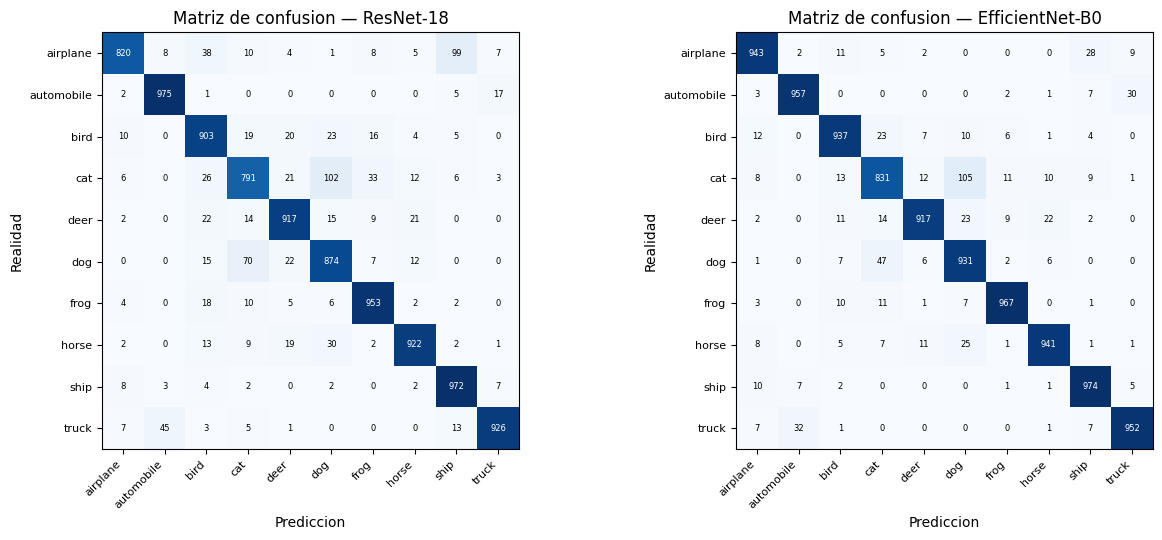

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


---
## 7. Reporte de diseño (completar en equipo)

Esta seccion es, literalmente, la evidencia **"Reporte de diseño"** del temario de la Unidad 1. Respondan cada punto con base en lo que observaron arriba — pueden editar esta celda de markdown directamente o copiar las respuestas a un documento aparte.

**1. Arquitectura y justificación**
> *(¿Cuál de las dos arquitecturas usarían si solo pudieran quedarse con una para este problema? Justifiquen con los números de la Parte 6, no solo con la teoría de 1.3.)*

* EfficientNet, los resultados en todas las metricas son superiores aunque sea más lento por cada epoch, pero en este caso el tiempo no es tan drastico como para que sea un factor que pese más que la mejora al generalizar

**2. Hiperparámetros usados**
>  Learning rate: `0.0001`  ·  Optimizador: `Adam`  ·  Épocas: `5`  ·  Batch size: `32`  ·  Tamaño del subconjunto de entrenamiento: `10000`  ·  Pesos iniciales: preentrenados (ImageNet)

**3. Estrategia de entrenamiento**
> *(¿Entrenaron con GPU o CPU? ¿Cuánto tardó cada época de cada modelo? Si tuvieran que reentrenar con más tiempo disponible, ¿qué cambiarían primero: más datos, más épocas, u otro hiperparámetro?)*

* Se entrenó usando CUDA, es decir GPU.
* El tiempo en Resnet fue alrededor de 40 segundos, mientras que en efficientNet fue de aproximadamente 59 segundos.
* Lo primero a cambiar sería usar más datos, en lugar de usar solo 10000 se podrían usar las 50000 imagenes de CIFAR-10.

**4. Diagnóstico de las curvas (conexión con 1.4)**
> *(¿Alguno de los dos modelos mostró señales de overfitting según el checklist de la diapositiva 21? ¿Cuál generalizó mejor — menor gap train/val, no necesariamente mayor accuracy?)*

* ResNet muestra señales muy claras de sobreajuste. Para la última epoch el accuracy era de 0.9956 pero la validación estaba estancada desde la epoch anterior.
* EfficientNet generalizó mejor, como se puede ver con un gap menor entre accuracy de entrenamiento y de validación.

**5. Capacidad vs. eficiencia (conexión con 1.3)**
> *(Con el número de parámetros de la Parte 2 y el accuracy final de la Parte 6: ¿cuál modelo ofrece mejor relación desempeño/costo computacional en este experimento?)*

* EfficientNet. Aunque es más lento durante el entrenamiento, EfficientNet está diseñado para maximizar rendimiento con menos parametros.

**6. Errores más frecuentes**
> *(Con las matrices de confusión de la Parte 6: ¿qué par de clases confunde más cada modelo? ¿Tiene sentido esa confusión dado lo que representan esas clases?)*

* En ambos modelos las clases que más se confunden son gato y perro. Tiene sentido ya que ambos tienen caracteristicas comunes y solo se pueden diferenciar en detalles concretos, como hocico y orejas, que las imagenes de 32x32 escaladas a 224x224 difuminarían mucho.

* ResNet también confundió bastantes barcos con aviones, probablemente por cuanto dominaría un fondo azul en ambos casos y el mismo problema que viene con escalar las imagenes fuente.

---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [x] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [x] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [x] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [x] Reporte de diseno (Parte 7) completado por el equipo.
- [x] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
